# Classification Model - HDB Town Prediction (KNN, Random Forest, XGBM, Light GBM and Cat Boost)

A step-by-step guide for building and evaluating K-Nearest Neighbors classification models.

**Objective:** Classify HDB towns based on property and location features.

---

## Step 1: Identify the Target Variable (y)

Define the categorical variable you want to predict (the dependent variable).

In [1]:
# ========== MODIFY THIS ==========
TARGET_COLUMN = 'town'  # Categorical target: town classification

# Note: TARGET_MAPPING will be created dynamically after loading data
# since there are many towns in Singapore
TARGET_MAPPING = None  # Will be populated in Step 3
# =================================

---

## Step 2: Import Packages and Load Dataset

In [2]:
# Import required libraries
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# Optional boosting libraries
try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None

# Configure plot settings
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 14
plt.style.use("fivethirtyeight")

# Suppress warnings
warnings.filterwarnings('ignore')

print("Packages imported successfully!")


Packages imported successfully!


In [3]:
# ========== MODIFY THIS ==========
from pathlib import Path

# Auto-detect dataset path to avoid path-related runtime failures
candidate_paths = [
    Path('data.csv'),
    Path('../data.csv'),
    Path('../Data/data.csv')
]

DATA_PATH = next((str(p) for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f"Could not find data.csv. Checked: {', '.join(str(p) for p in candidate_paths)}")
# =================================

df = pd.read_csv(DATA_PATH)
print(f"Using dataset: {DATA_PATH}")

# Create TARGET_MAPPING dynamically from unique town values
TARGET_MAPPING = {town: idx for idx, town in enumerate(sorted(df[TARGET_COLUMN].unique()))}
print(f"Towns found: {len(TARGET_MAPPING)}")

# Preview the data
print(f"\nDataset loaded with shape: {df.shape}")
df.head()

Using dataset: ../Data/data.csv
Towns found: 26

Dataset loaded with shape: (270619, 76)


,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,2012-03,ANG MO KIO,5 ROOM,101,ANG MO KIO AVE 3,06 TO 10,117.0,Standard,1978,515000.0,...,61.0,0.0,1.369092,103.839041,474.789674,Ang Mo Kio Secondary School,224.0,0.0,1.367359,103.842600
1,2012-03,ANG MO KIO,3 ROOM,103,ANG MO KIO AVE 3,06 TO 10,73.0,New Generation,1978,368000.0,...,61.0,0.0,1.369092,103.839041,522.935557,Mayflower Secondary School,219.0,0.0,1.368337,103.835439
2,2012-03,ANG MO KIO,4 ROOM,105,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,430000.0,...,61.0,0.0,1.369092,103.839041,398.421190,CHIJ Saint Nicholas Girls' School,256.0,1.0,1.373730,103.834309
3,2012-03,ANG MO KIO,4 ROOM,108,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,427000.0,...,61.0,0.0,1.369092,103.839041,424.046635,Mayflower Secondary School,219.0,0.0,1.368337,103.835439
4,2012-03,ANG MO KIO,3 ROOM,110,ANG MO KIO AVE 4,01 TO 05,67.0,New Generation,1978,323000.0,...,61.0,0.0,1.369092,103.839041,322.732547,Mayflower Secondary School,219.0,0.0,1.368337,103.835439


---

## Step 3: Explore the Dataset Structure

Check the number of features, data types, and basic statistics.

In [4]:
# Check dimensions (rows, columns)
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print("\n" + "="*50)

# Check for missing values
print("\nMissing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0])

# View column names and data types
print("\nColumn Info:")
df.info()

Dataset shape: (270619, 76)
Number of features: 76


Missing values per column:
Mall_Nearest_Distance      5210
Mall_Within_500m         168137
Mall_Within_1km           49132
Mall_Within_2km            7036
Hawker_Within_500m       177013
Hawker_Within_1km        109046
Hawker_Within_2km         52516
dtype: int64

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270619 entries, 0 to 270618
Data columns (total 76 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Tranc_YearMonth            270619 non-null  object 
 1   town                       270619 non-null  object 
 2   flat_type                  270619 non-null  object 
 3   block                      270619 non-null  object 
 4   street_name                270619 non-null  object 
 5   storey_range               270619 non-null  object 
 6   floor_area_sqm             270619 non-null  float64
 7   flat_model                 270619 non-nu

In [5]:
# View basic statistics
df.describe()

,floor_area_sqm,lease_commence_date,resale_price,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,floor_area_sqft,...,pri_sch_nearest_distance,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
count,270619.000000,270619.000000,2.706190e+05,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,...,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000
mean,96.688538,1994.860209,5.077318e+05,2019.382867,6.569993,8.540509,7.520218,9.560800,8.540509,1040.751170,...,410.333804,49.501099,0.110421,1.367462,103.839956,524.446040,119.498162,0.036088,1.367066,103.840203
std,24.158391,13.743470,1.758274e+05,3.938842,3.322633,5.753127,5.757832,5.751876,5.753127,260.039993,...,246.979262,20.722907,0.313414,0.042797,0.071881,315.536641,97.268801,0.186509,0.042629,0.071779
min,31.000000,1966.000000,1.500000e+05,2012.000000,1.000000,2.000000,1.000000,3.000000,2.000000,333.680900,...,42.554863,0.000000,0.000000,1.274962,103.687588,38.913475,5.000000,0.000000,1.276029,103.687207
25%,76.000000,1984.000000,3.800000e+05,2016.000000,4.000000,5.000000,4.000000,6.000000,5.000000,818.056400,...,232.375000,32.000000,0.000000,1.337408,103.776108,297.943031,19.000000,0.000000,1.338179,103.777148
50%,93.000000,1995.000000,4.730000e+05,2020.000000,7.000000,8.000000,7.000000,9.000000,8.000000,1001.052000,...,361.106748,48.000000,0.000000,1.365518,103.844934,459.407453,188.000000,0.000000,1.367107,103.844934
75%,112.000000,2004.000000,6.038880e+05,2023.000000,9.000000,11.000000,10.000000,12.000000,11.000000,1205.556800,...,524.571779,64.000000,0.000000,1.394958,103.898773,669.551509,211.000000,0.000000,1.396218,103.899872
max,366.700000,2022.000000,1.658888e+06,2025.000000,12.000000,50.000000,49.000000,51.000000,50.000000,3947.122130,...,3306.003143,138.000000,1.000000,1.456667,103.962919,3638.977233,260.000000,1.000000,1.453280,103.961105


In [6]:
# ========== DEFINE COLUMNS TO USE ==========
# Detect missing values in required columns and drop rows with nulls

COLUMNS_TO_USE = [
    'Mall_Nearest_Distance',
    'mrt_nearest_distance',
    'Hawker_Nearest_Distance',
    'hdb_age',
    'max_floor_lvl',
    # Target
    'town',
]

# ===========================================
# Validate required columns are present

missing_required_cols = [col for col in COLUMNS_TO_USE if col not in df.columns]
if missing_required_cols:
    raise ValueError(f"Missing required columns in dataset: {missing_required_cols}")

# Diagnostic: show missing values for the columns used by the model
missing_before = df[COLUMNS_TO_USE].isna().sum().sort_values(ascending=False)

print("Missing values before cleanup (columns used):")
print(missing_before.to_string())
print(f"\nTotal missing values before cleanup (columns used): {int(missing_before.sum())}")

# Drop rows with null values in required columns
rows_before = len(df)
df = df.dropna(subset=COLUMNS_TO_USE).reset_index(drop=True)
rows_after = len(df)
rows_dropped = rows_before - rows_after

missing_after = df[COLUMNS_TO_USE].isna().sum().sort_values(ascending=False)

print("\nMissing values after cleanup (columns used):")
print(missing_after.to_string())
print(f"\nTotal missing values after cleanup (columns used): {int(missing_after.sum())}")

print(f"\nRows before cleanup: {rows_before}")
print(f"Rows after cleanup: {rows_after}")
print(f"Rows dropped: {rows_dropped}")

Missing values before cleanup (columns used):
Mall_Nearest_Distance      5210
mrt_nearest_distance          0
Hawker_Nearest_Distance       0
hdb_age                       0
max_floor_lvl                 0
town                          0

Total missing values before cleanup (columns used): 5210

Missing values after cleanup (columns used):
Mall_Nearest_Distance      0
mrt_nearest_distance       0
Hawker_Nearest_Distance    0
hdb_age                    0
max_floor_lvl              0
town                       0

Total missing values after cleanup (columns used): 0

Rows before cleanup: 270619
Rows after cleanup: 265409
Rows dropped: 5210


---

## Step 3.5: Feature Engineering (Optional)

Create new features by combining or transforming existing columns. This can help capture relationships that improve model performance.

**Common feature engineering techniques for KNN:**
- **Ratio features**: e.g., `floor_ratio = mid_storey / max_floor_lvl` (relative floor position)
- **Interaction features**: e.g., `area_per_floor = floor_area_sqm / max_floor_lvl`
- **Distance scores**: e.g., combining multiple distance features

> **Note:** KNN uses distance calculations, so engineered features should be on similar scales. Feature scaling (StandardScaler) in Step 5 will handle this.

Fallback used: live_pri built from pri_sch_nearest_distance + pri_sch_affiliation
Fallback used: school_tier_encoded missing, live_sec uses proximity only
Town Liveability Rankings:

                 liveability  pri_school  sec_school    mrt  hawker   mall
town                                                                      
CENTRAL AREA           0.700       0.586       0.706  0.755   0.716  0.729
BISHAN                 0.696       0.787       0.895  0.749   0.588  0.423
BUKIT PANJANG          0.693       0.634       0.879  0.834   0.529  0.511
GEYLANG                0.684       0.788       0.829  0.685   0.658  0.453
PUNGGOL                0.662       0.674       0.877  0.887   0.218  0.486
SENGKANG               0.659       0.655       0.888  0.762   0.397  0.501
TAMPINES               0.656       0.665       0.886  0.680   0.552  0.466
HOUGANG                0.652       0.765       0.898  0.537   0.573  0.498
WOODLANDS              0.651       0.627       0.892  0.644   0.601

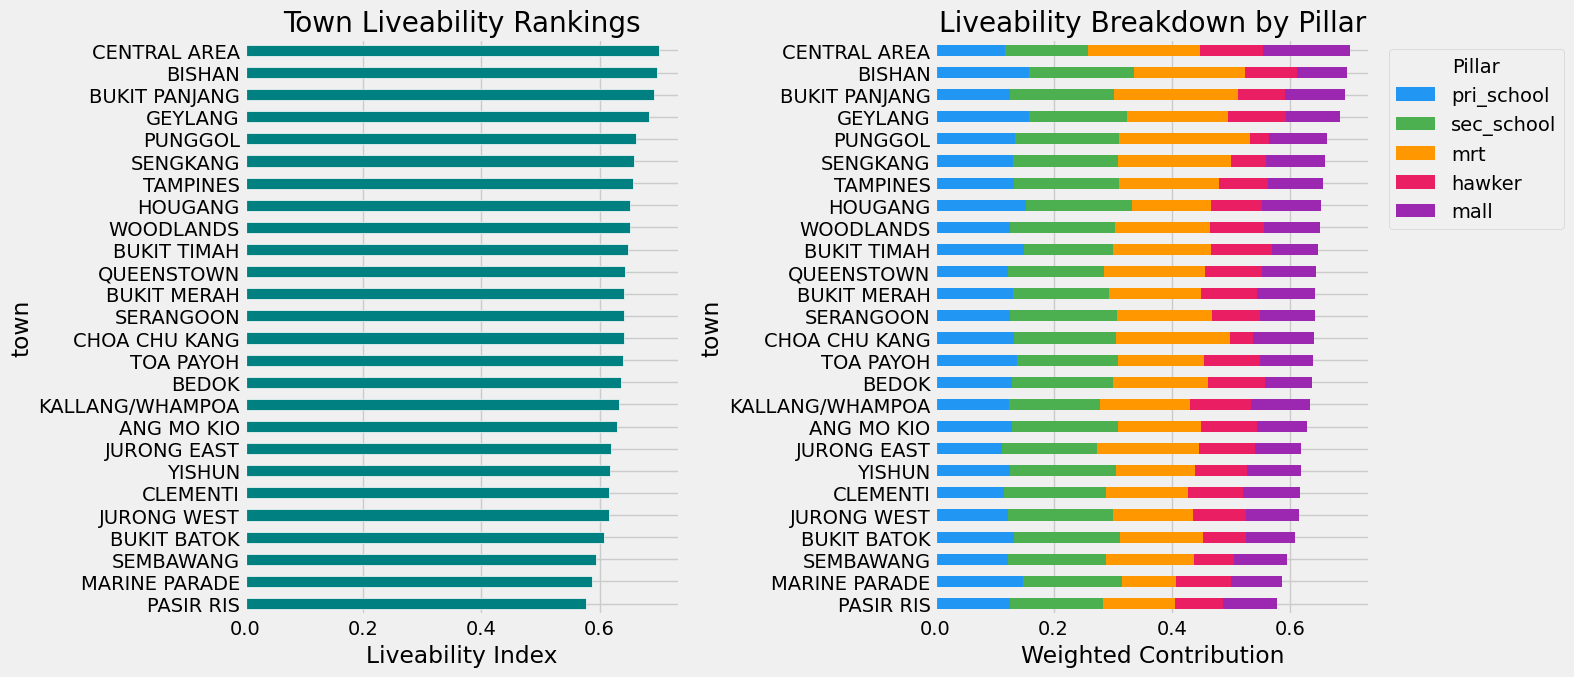

In [7]:
# ========== FEATURE ENGINEERING SECTION ==========

# Add new engineered features below. Each feature is created from existing columns.

# ============================================================
# Town Liveability Index
# ============================================================
# Combines 5 pillars - each scored 0-1 per transaction, then
# averaged per town. Within each pillar the score scales UP
# with quality/prestige AND proximity/count.


def build_liveability(df):
    df = df.copy()

    # Columns that must exist in this dataset
    required_columns = [
        'sec_sch_nearest_dist',
        'mrt_nearest_distance',
        'mrt_interchange',
        'Hawker_Nearest_Distance',
        'hawker_food_stalls',
        'Mall_Nearest_Distance',
        'Mall_Within_2km',
        'pri_sch_nearest_distance',
        'pri_sch_affiliation',
    ]
    missing = [c for c in required_columns if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns for liveability features: {missing}")

    # Helper: min-max scale a series to [0, 1]
    def minmax(s):
        s = s.astype(float)
        span = s.max() - s.min()
        if pd.isna(span) or span == 0:
            return pd.Series(0.0, index=s.index)
        return (s - s.min()) / span

    # ---------- 1. PRIMARY SCHOOL ----------
    # Build prestige proxy from proximity + affiliation when
    # primary_school_prestige_index is unavailable.
    if 'primary_school_prestige_index' in df.columns:
        df['live_pri'] = minmax(df['primary_school_prestige_index'])
    else:
        pri_prox = minmax(df['pri_sch_nearest_distance'].max() - df['pri_sch_nearest_distance'])
        pri_aff = minmax(df['pri_sch_affiliation'].fillna(0))
        df['live_pri'] = 0.7 * pri_prox + 0.3 * pri_aff
        print("Fallback used: live_pri built from pri_sch_nearest_distance + pri_sch_affiliation")

    # ---------- 2. SECONDARY SCHOOL ----------
    sec_prox = minmax(df['sec_sch_nearest_dist'].max() - df['sec_sch_nearest_dist'])

    # Use school quality only if the column exists
    if 'school_tier_encoded' in df.columns:
        sec_qual = (2 - df['school_tier_encoded']) / 1.0   # 1 -> 1, 2 -> 0
        df['live_sec'] = 0.5 * sec_prox + 0.5 * sec_qual
    else:
        df['live_sec'] = sec_prox
        print("Fallback used: school_tier_encoded missing, live_sec uses proximity only")

    # ---------- 3. MRT ----------
    mrt_prox = minmax(df['mrt_nearest_distance'].max() - df['mrt_nearest_distance'])
    mrt_inter = df['mrt_interchange'].clip(0, 1)
    df['live_mrt'] = 0.7 * mrt_prox + 0.3 * mrt_inter

    # ---------- 4. HAWKER ----------
    hawk_prox = minmax(df['Hawker_Nearest_Distance'].max() - df['Hawker_Nearest_Distance'])
    hawk_stalls = minmax(df['hawker_food_stalls'])
    df['live_hawker'] = 0.6 * hawk_prox + 0.4 * hawk_stalls

    # ---------- 5. MALL ----------
    mall_prox = minmax(df['Mall_Nearest_Distance'].max() - df['Mall_Nearest_Distance'])
    mall_count = minmax(df['Mall_Within_2km'].fillna(0))
    df['live_mall'] = 0.5 * mall_prox + 0.5 * mall_count

    # Final transaction-level liveability index
    df['liveability_index'] = (
        0.20 * df['live_pri']
        + 0.20 * df['live_sec']
        + 0.25 * df['live_mrt']
        + 0.15 * df['live_hawker']
        + 0.20 * df['live_mall']
    )

    return df


df = build_liveability(df)

PILLARS = ['live_pri', 'live_sec', 'live_mrt', 'live_hawker', 'live_mall']
df[PILLARS] = df[PILLARS].fillna(0)

TARGET_COLUMN = 'town'
FEATURE_COLUMNS = PILLARS
df = df.dropna(subset=[TARGET_COLUMN])
df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(str)

# Aggregate to town level (diagnostic view)
town_live = (
    df.groupby('town')
    .agg(
        liveability=('liveability_index', 'mean'),
        pri_school=('live_pri', 'mean'),
        sec_school=('live_sec', 'mean'),
        mrt=('live_mrt', 'mean'),
        hawker=('live_hawker', 'mean'),
        mall=('live_mall', 'mean'),
        avg_resale=('resale_price', 'mean'),
        n_transactions=('resale_price', 'size'),
    )
    .sort_values('liveability', ascending=False)
)

print('Town Liveability Rankings:\n')
print(town_live[['liveability', 'pri_school', 'sec_school', 'mrt', 'hawker', 'mall']].round(3).to_string())

# Correlation with resale_price (transaction-level)
r = df['resale_price'].corr(df['liveability_index'])
print(f"\nCorrelation between liveability_index and resale_price: {r:.4f}")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar chart: town rankings
town_live['liveability'].sort_values().plot(
    kind='barh', ax=axes[0], color='teal', edgecolor='white'
)
axes[0].set_xlabel('Liveability Index')
axes[0].set_title('Town Liveability Rankings')

# Stacked breakdown
pillar_cols = ['pri_school', 'sec_school', 'mrt', 'hawker', 'mall']
weights = [0.20, 0.20, 0.25, 0.15, 0.20]
weighted = town_live[pillar_cols].multiply(weights).loc[town_live['liveability'].sort_values().index]
weighted.plot(
    kind='barh',
    stacked=True,
    ax=axes[1],
    color=['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0'],
)
axes[1].set_xlabel('Weighted Contribution')
axes[1].set_title('Liveability Breakdown by Pillar')
axes[1].legend(title='Pillar', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

Target variable distribution (town):
town
SENGKANG           19939
WOODLANDS          19586
JURONG WEST        18831
TAMPINES           18618
YISHUN             18156
PUNGGOL            15791
BEDOK              14980
HOUGANG            13652
ANG MO KIO         11510
CHOA CHU KANG      11277
BUKIT BATOK        11214
BUKIT MERAH        10057
BUKIT PANJANG       9526
TOA PAYOH           8523
KALLANG/WHAMPOA     8045
PASIR RIS           7897
SEMBAWANG           7884
QUEENSTOWN          7057
GEYLANG             6799
CLEMENTI            6140
JURONG EAST         5621
SERANGOON           5066
BISHAN              4747
CENTRAL AREA        2147
MARINE PARADE       1717
BUKIT TIMAH          629
Name: count, dtype: int64


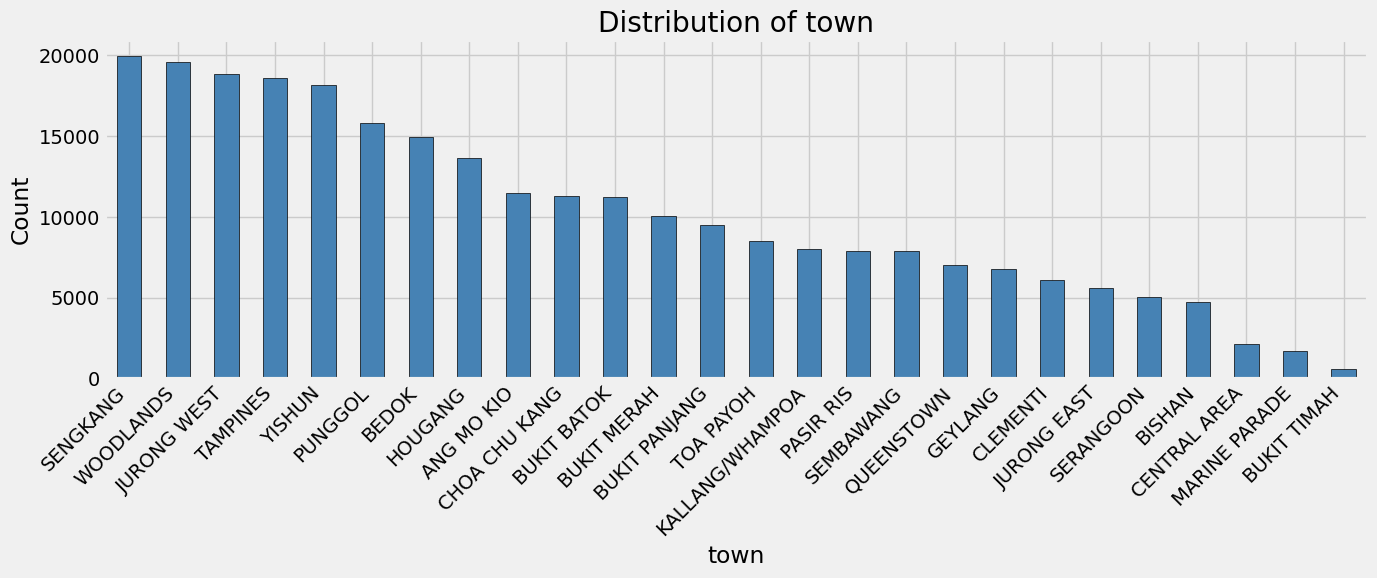

In [8]:
# Check target variable distribution
print(f"Target variable distribution ({TARGET_COLUMN}):")
print(df[TARGET_COLUMN].value_counts())

# Visualize target distribution
plt.figure(figsize=(14, 6))
df[TARGET_COLUMN].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title(f'Distribution of {TARGET_COLUMN}')
plt.xlabel(TARGET_COLUMN)
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---

## Step 4: Exploratory Data Analysis (EDA) - Feature Distributions

For KNN classification, **correlation analysis is not as important** as it is for linear models. KNN is a distance-based algorithm that doesn't assume linear relationships between features and the target.

**What matters for KNN:**
- How well features **separate the classes** (visualized with boxplots)
- Feature **scale** (addressed with StandardScaler in Step 5)
- Feature **distribution** within each class

### 4a. Feature Distribution by Target Class (Boxplots)

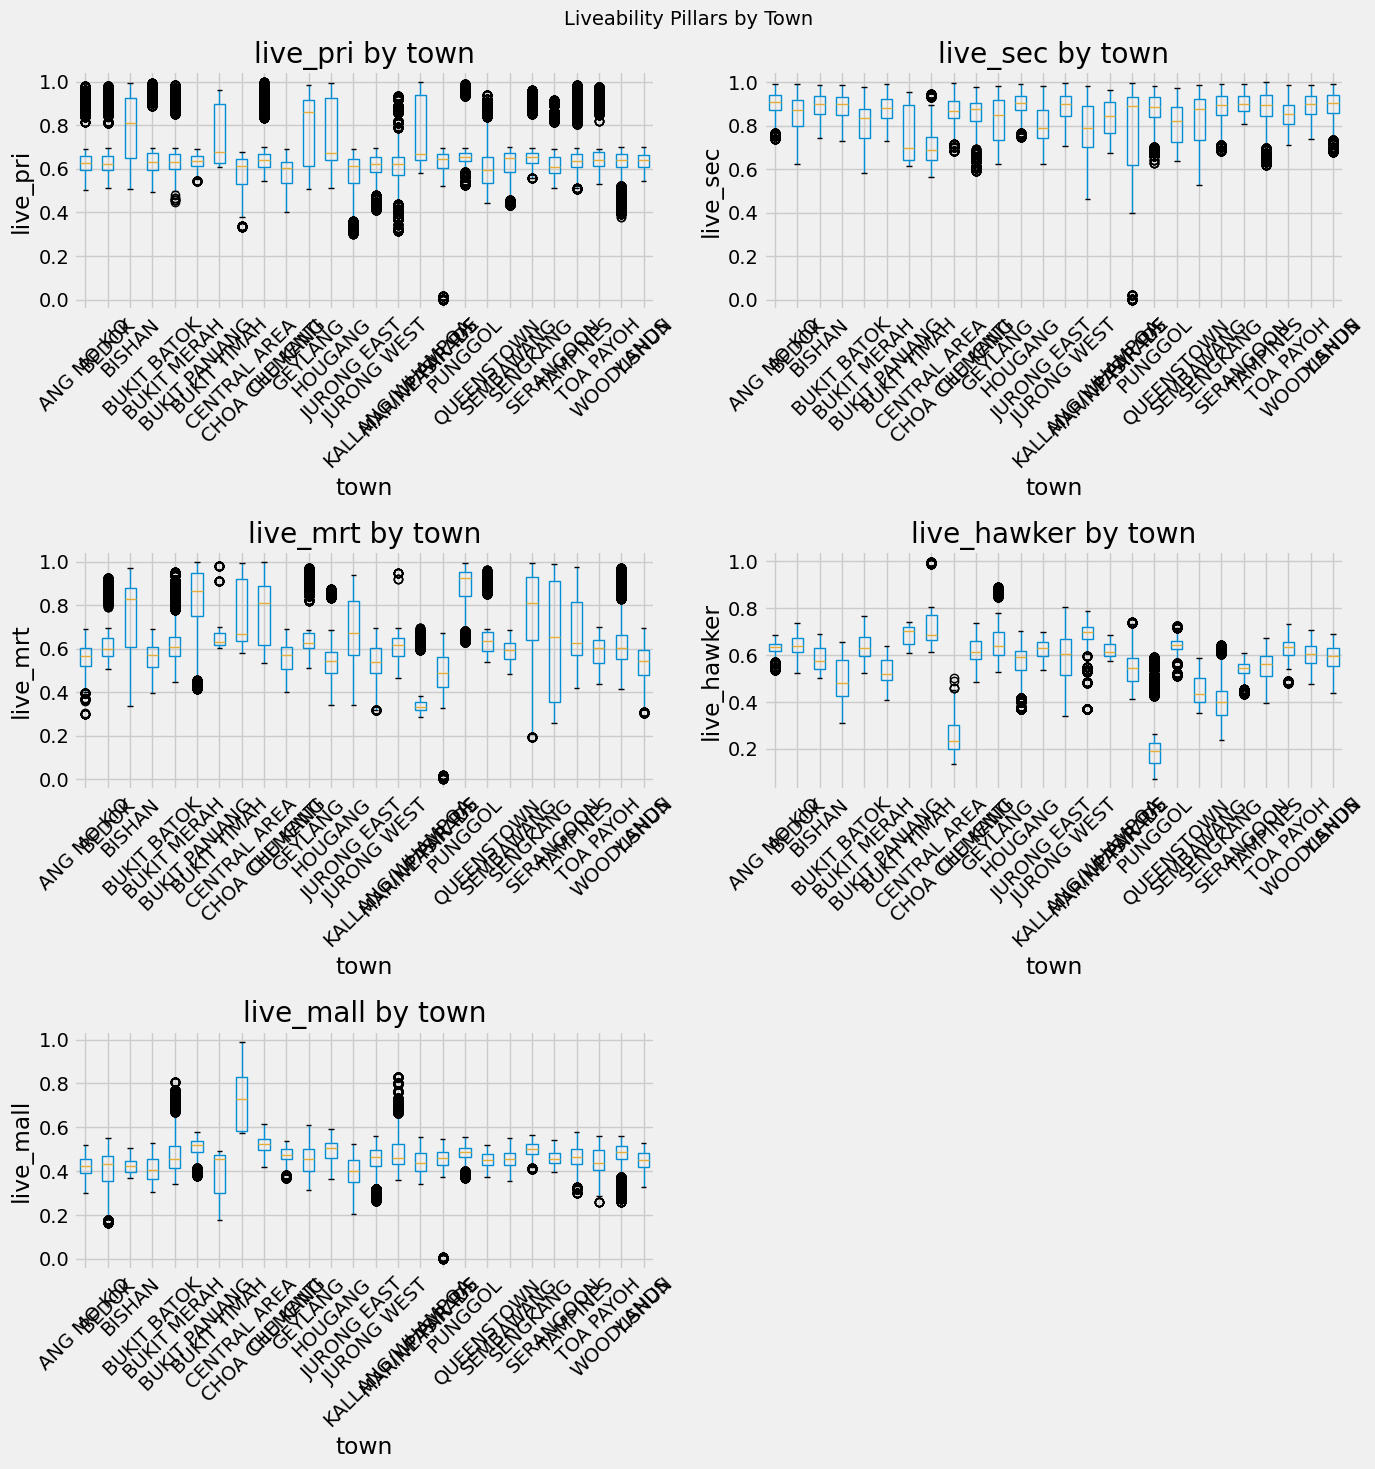

In [9]:
# ========== MODIFY THIS ==========
# Use the 5 liveability pillars for class-separation inspection
FEATURES_TO_PLOT = PILLARS
# =================================

# Box plots for key features by target class
# This shows how well each feature separates the different classes
n_features = len(FEATURES_TO_PLOT)
n_cols = 2
n_rows = (n_features + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(FEATURES_TO_PLOT):
    if col in df.columns:
        df.boxplot(column=col, by=TARGET_COLUMN, ax=axes[i])
        axes[i].set_title(f'{col} by {TARGET_COLUMN}')
        axes[i].set_xlabel(TARGET_COLUMN)
        axes[i].set_ylabel(col)
        axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots if odd number of features
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Liveability Pillars by Town', fontsize=14)
plt.tight_layout()
plt.show()

**Interpreting Boxplots for KNN:**
- **Good features:** Show clear separation between classes (minimal overlap in boxes)
- **Less useful features:** Classes overlap significantly
- Features with better class separation will contribute more to accurate KNN predictions

### 4b. Class Separation Summary

In [10]:
# Calculate mean values per class to understand feature separation
class_means = df.groupby(TARGET_COLUMN)[FEATURES_TO_PLOT].mean()
print("Mean feature values by town:")
display(class_means.round(2))

Mean feature values by town:


,live_pri,live_sec,live_mrt,live_hawker,live_mall
town,,,,,
ANG MO KIO,0.64,0.90,0.56,0.63,0.42
BEDOK,0.65,0.86,0.64,0.64,0.40
BISHAN,0.79,0.90,0.75,0.59,0.42
BUKIT BATOK,0.67,0.89,0.56,0.50,0.41
BUKIT MERAH,0.65,0.81,0.62,0.64,0.49
BUKIT PANJANG,0.63,0.88,0.83,0.53,0.51
BUKIT TIMAH,0.75,0.75,0.66,0.68,0.39
CENTRAL AREA,0.59,0.71,0.75,0.72,0.73
CHOA CHU KANG,0.66,0.87,0.77,0.26,0.52


In [11]:
# Calculate standard deviation to understand spread
class_std = df.groupby(TARGET_COLUMN)[FEATURES_TO_PLOT].std()
print("Standard deviation by town:")
display(class_std.round(2))

Standard deviation by town:


,live_pri,live_sec,live_mrt,live_hawker,live_mall
town,,,,,
ANG MO KIO,0.09,0.05,0.06,0.02,0.04
BEDOK,0.09,0.08,0.11,0.04,0.10
BISHAN,0.14,0.06,0.17,0.05,0.03
BUKIT BATOK,0.12,0.06,0.06,0.08,0.05
BUKIT MERAH,0.10,0.10,0.10,0.06,0.11
BUKIT PANJANG,0.03,0.06,0.14,0.05,0.04
BUKIT TIMAH,0.13,0.12,0.09,0.04,0.11
CENTRAL AREA,0.08,0.09,0.15,0.08,0.14
CHOA CHU KANG,0.09,0.06,0.14,0.08,0.04


### 4c. Optional: Correlation Matrix (for Multicollinearity Check Only)

> **Note:** Correlation is not used for feature-target relationship in KNN, but can help identify **multicollinearity** (highly correlated features that may be redundant).

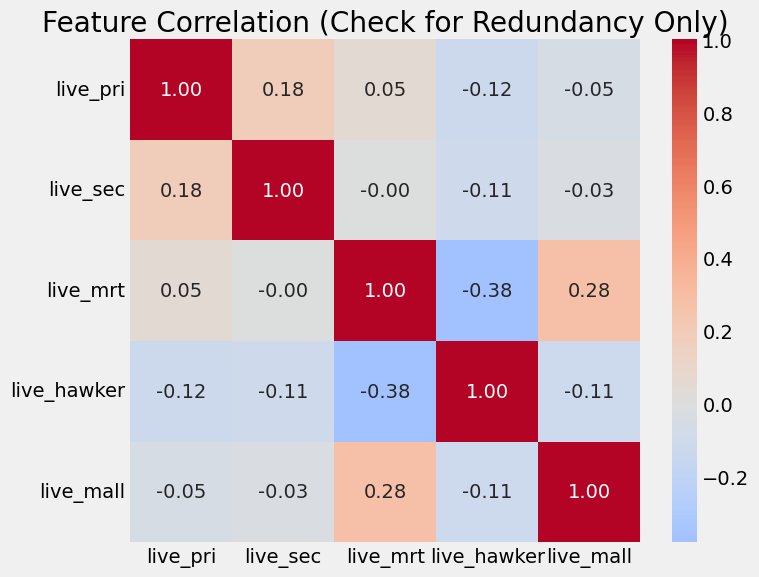


Highly correlated feature pairs (|r| > 0.8):
  None found - features are not highly correlated with each other.


In [12]:
# Optional: Check for redundant features (multicollinearity)
numeric_cols = df[FEATURES_TO_PLOT]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Feature Correlation (Check for Redundancy Only)')
plt.tight_layout()
plt.show()

# Flag highly correlated feature pairs (consider removing one)
CORRELATION_THRESHOLD = 0.8
print(f"\nHighly correlated feature pairs (|r| > {CORRELATION_THRESHOLD}):")
found_high_corr = False
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > CORRELATION_THRESHOLD:
            print(f"  {corr_matrix.columns[i]} & {corr_matrix.columns[j]} = {corr_matrix.iloc[i, j]:.2f}")
            found_high_corr = True
if not found_high_corr:
    print("  None found - features are not highly correlated with each other.")

---

## Step 5: Model Preprocessing

### 5a. Map Categorical Labels to Numeric Labels

In [13]:
# ========== MODIFY THIS ==========
TARGET_NUMERIC_COL = 'town_num'  # Name for the new numeric column
# =================================

# Map target to numeric values
df[TARGET_NUMERIC_COL] = df[TARGET_COLUMN].map(TARGET_MAPPING)

# Check for any unmapped values (NaN)
unmapped = df[df[TARGET_NUMERIC_COL].isna()][TARGET_COLUMN].unique()
if len(unmapped) > 0:
    print(f"WARNING: Unmapped values found: {unmapped}")
    print("Update TARGET_MAPPING to include these values.")
else:
    print("All target values successfully mapped!")

# Verify mapping
print("\nTarget mapping verification:")
print(df[[TARGET_COLUMN, TARGET_NUMERIC_COL]].drop_duplicates().sort_values(TARGET_NUMERIC_COL))

All target values successfully mapped!

Target mapping verification:
                 town  town_num
0          ANG MO KIO         0
98              BEDOK         1
208            BISHAN         2
248       BUKIT BATOK         3
333       BUKIT MERAH         4
415     BUKIT PANJANG         5
459       BUKIT TIMAH         6
464      CENTRAL AREA         7
473     CHOA CHU KANG         8
572          CLEMENTI         9
613           GEYLANG        10
678           HOUGANG        11
778       JURONG EAST        12
829       JURONG WEST        13
978   KALLANG/WHAMPOA        14
1030    MARINE PARADE        15
1043        PASIR RIS        16
1095          PUNGGOL        17
1175       QUEENSTOWN        18
1228        SEMBAWANG        19
1262         SENGKANG        20
1352        SERANGOON        21
1396         TAMPINES        22
1532        TOA PAYOH        23
1597        WOODLANDS        24
1774           YISHUN        25


### 5b. Define Feature Columns and Set X and y

In [14]:
# ========== MODIFY THIS ==========
# Use only the 5 liveability pillars for model training
PILLARS = ['live_pri', 'live_sec', 'live_mrt', 'live_hawker', 'live_mall']
df[PILLARS] = df[PILLARS].fillna(0)

TARGET_COLUMN = 'town'
FEATURE_COLUMNS = PILLARS
df = df.dropna(subset=[TARGET_COLUMN])
df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(str)

# Create a grouping key to prevent leakage
# Best practical option:
df['group_key'] = df['block'].astype(str) + '_' + df['street_name'].astype(str)

# If you want to try address instead, use this instead:
# df['group_key'] = df['address'].astype(str)
# =================================

# Verify all features exist in dataframe
missing_cols = [col for col in FEATURE_COLUMNS if col not in df.columns]
if missing_cols:
    print(f"WARNING: Missing columns: {missing_cols}")
    print('Make sure to run the Feature Engineering cell (Step 3.5) first!')
else:
    print(f"All {len(FEATURE_COLUMNS)} features found in dataset")
    print(f"  - Features: {FEATURE_COLUMNS}")

# Create feature matrix (X) and target vector (y)
X = df[FEATURE_COLUMNS]
y = df[TARGET_NUMERIC_COL]
groups = df['group_key']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of groups: {groups.nunique()}")

All 5 features found in dataset
  - Features: ['live_pri', 'live_sec', 'live_mrt', 'live_hawker', 'live_mall']

X shape: (265409, 5)
y shape: (265409,)
Number of groups: 9579


In [ ]:
# pd.concat([X, y], axis=1).to_csv('classification_first_permutation.csv', index=False)

### 5c. Split Data into Training and Testing Sets


In [15]:
from sklearn.model_selection import GroupShuffleSplit

# ========== MODIFY THIS ==========
RANDOM_STATE = 42
TEST_SIZE = 0.25
# =================================

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

train_groups = set(groups.iloc[train_idx])
test_groups = set(groups.iloc[test_idx])

print(f"Training set size: {X_train.shape[0]:,} rows")
print(f"Testing set size:  {X_test.shape[0]:,} rows")
print(f"Train groups: {len(train_groups):,}")
print(f"Test groups:  {len(test_groups):,}")
print(f"Group overlap: {len(train_groups & test_groups)}")
print(f"All towns in train? {y_train.nunique() == len(TARGET_MAPPING)}")
print(f"All towns in test?  {y_test.nunique() == len(TARGET_MAPPING)}")

Training set size: 199,126 rows
Testing set size:  66,283 rows
Train groups: 7,184
Test groups:  2,395
Group overlap: 0
All towns in train? True
All towns in test?  True


### 5d. Feature Scaling with StandardScaler

**Why Scale?** KNN uses distance calculations, so features with larger scales can dominate the distance metric. StandardScaler normalizes features to have mean=0 and std=1.

In [16]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data ONLY, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier inspection (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLUMNS)

print("Scaled training data statistics:")
print(X_train_scaled_df.describe().round(2))

Scaled training data statistics:
        live_pri   live_sec   live_mrt  live_hawker  live_mall
count  199126.00  199126.00  199126.00    199126.00  199126.00
mean       -0.00      -0.00      -0.00         0.00      -0.00
std         1.00       1.00       1.00         1.00       1.00
min        -6.32      -9.99      -4.03        -3.25      -6.61
25%        -0.48      -0.46      -0.63        -0.42      -0.52
50%        -0.13       0.20      -0.24         0.29       0.05
75%         0.15       0.72       0.59         0.66       0.56
max         3.32       1.54       2.20         3.16       7.46


In [17]:
# ========== SMOTE ON TRAINING DATA (MANDATORY) ==========
# Apply SMOTE to TRAINING data only to avoid data leakage.
# This notebook now always uses SMOTE and no longer keeps optional KNN-era toggles.
# ========================================================

_X_train_base = X_train.copy()
_y_train_base = y_train.copy()
_X_test_base = X_test.copy()
_y_test_base = y_test.copy()

# Always start from base split
X_train = _X_train_base.copy()
y_train = _y_train_base.copy()
X_test = _X_test_base.copy()
y_test = _y_test_base.copy()

# Apply SMOTE on training set only
smote = SMOTE(random_state=RANDOM_STATE)
X_train, y_train = smote.fit_resample(X_train, y_train)
print("SMOTE applied to training data only.")

# Prepare XGBoost-safe labels once (consecutive integers from 0)
xgb_label_encoder = LabelEncoder()
y_train_xgb = xgb_label_encoder.fit_transform(y_train)

missing_test_classes = set(np.unique(y_test)) - set(xgb_label_encoder.classes_)
if missing_test_classes:
    raise ValueError(f"XGBoost label encoding issue. Classes in test but not train: {sorted(missing_test_classes)}")

y_test_xgb = xgb_label_encoder.transform(y_test)
print("XGBoost label mapping prepared in preprocessing.")

# Scale AFTER final training data is set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train rows after SMOTE: {len(y_train):,} | Test rows: {len(y_test):,}")
print("Leakage guard: scaler is fit on training data only.")

SMOTE applied to training data only.
XGBoost label mapping prepared in preprocessing.
Train rows after SMOTE: 393,484 | Test rows: 66,283
Leakage guard: scaler is fit on training data only.


---

## Step 6: Find Optimal K Value

Iterate through different K values to find the one that minimizes testing error.

In [18]:
# ========== MODIFY THIS ==========
K_MIN = 1
K_MAX = 50
K_STEP = 2  # Use odd numbers to avoid ties
# =================================

# Calculate training and testing error for different K values
k_range = list(range(K_MIN, K_MAX, K_STEP))
training_error = []
testing_error = []

for k in k_range:
    # Instantiate and fit the model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Calculate training error (error = 1 - accuracy)
    training_accuracy = knn.score(X_train_scaled, y_train)
    training_error.append(1 - training_accuracy)
    
    # Calculate testing error
    testing_accuracy = knn.score(X_test_scaled, y_test)
    testing_error.append(1 - testing_accuracy)

# Create results DataFrame
results_df = pd.DataFrame({
    'K': k_range,
    'training_error': training_error,
    'testing_error': testing_error,
    'training_accuracy': [1 - e for e in training_error],
    'testing_accuracy': [1 - e for e in testing_error]
}).set_index('K')

print("Top 10 K values (lowest testing error):")
print(results_df.sort_values('testing_error').head(10))

Top 10 K values (lowest testing error):
    training_error  testing_error  training_accuracy  testing_accuracy
K                                                                     
1         0.000000       0.098260           1.000000          0.901740
3         0.000010       0.098834           0.999990          0.901166
5         0.000038       0.099301           0.999962          0.900699
11        0.000216       0.099935           0.999784          0.900065
7         0.000066       0.099980           0.999934          0.900020
13        0.000264       0.100101           0.999736          0.899899
9         0.000132       0.100222           0.999868          0.899778
15        0.000379       0.100825           0.999621          0.899175
21        0.000734       0.101248           0.999266          0.898752
17        0.000455       0.101670           0.999545          0.898330


### Visualize Training vs Testing Error

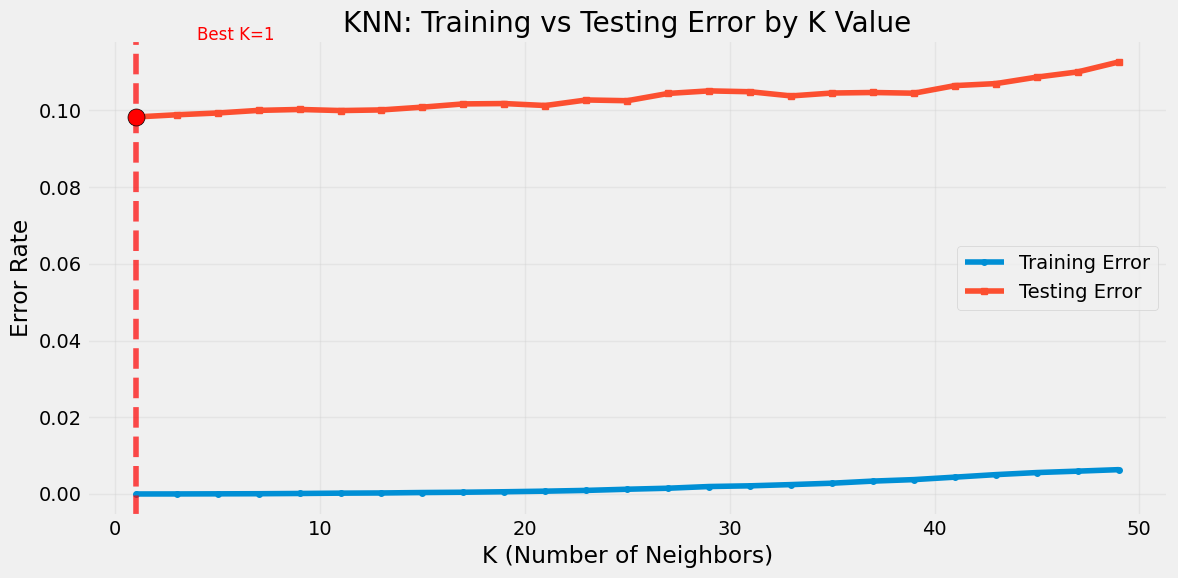


Optimal K value: 1
Testing error at K=1: 0.0983
Testing accuracy at K=1: 0.9017


In [19]:
# Plot error curves
plt.figure(figsize=(12, 6))
plt.plot(k_range, training_error, label='Training Error', marker='o', markersize=4)
plt.plot(k_range, testing_error, label='Testing Error', marker='s', markersize=4)
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Error Rate')
plt.title('KNN: Training vs Testing Error by K Value')
plt.legend()
plt.grid(True, alpha=0.3)

# Mark the optimal K
best_k = results_df['testing_error'].idxmin()
best_error = results_df.loc[best_k, 'testing_error']
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
plt.scatter([best_k], [best_error], color='red', s=150, zorder=5, edgecolor='black')
plt.annotate(f'Best K={best_k}', xy=(best_k, best_error), xytext=(best_k+3, best_error+0.02),
             fontsize=12, color='red')

plt.tight_layout()
plt.show()

print(f"\nOptimal K value: {best_k}")
print(f"Testing error at K={best_k}: {best_error:.4f}")
print(f"Testing accuracy at K={best_k}: {1 - best_error:.4f}")

---

## Step 7: Train Final Model and Evaluate

Train the model with the optimal K value and evaluate performance.

In [20]:
# Find best K from results
best_k = results_df['testing_error'].idxmin()

# Train final model
start = time.perf_counter()
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
knn_runtime = time.perf_counter() - start

# Calculate scores
train_accuracy = knn_final.score(X_train_scaled, y_train)
test_accuracy = knn_final.score(X_test_scaled, y_test)
train_error = 1 - train_accuracy
test_error = 1 - test_accuracy

# Store results in same format as other models
knn_results = {
    'Model': f'KNN (K={best_k})',
    'Train Accuracy': train_accuracy,
    'Test Accuracy': test_accuracy,
    'Runtime (sec)': knn_runtime,
    'Feature Importance': pd.DataFrame(columns=['Feature', 'Importance']),
    'fitted_model': knn_final
}

# Display results
print("=" * 60)
print("                  FINAL MODEL PERFORMANCE")
print("=" * 60)
print(f"Best K Value: {best_k}")
print()
print(f"  train_accuracy: {train_accuracy:.4f}")
print(f"  test_accuracy:  {test_accuracy:.4f}")
print()
print(f"  train_error:    {train_error:.4f}")
print(f"  test_error:     {test_error:.4f}")
print("=" * 60)


                  FINAL MODEL PERFORMANCE
Best K Value: 1

  train_accuracy: 1.0000
  test_accuracy:  0.9017

  train_error:    0.0000
  test_error:     0.0983


### Detailed Classification Report

In [21]:
# Make predictions
y_pred = knn_final.predict(X_test_scaled)

# Get the class labels that are actually present in the data
present_classes = sorted(y.unique())
present_labels = [k for k, v in sorted(TARGET_MAPPING.items(), key=lambda x: x[1]) if v in present_classes]

# Classification report
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred, target_names=present_labels, zero_division=0))

Classification Report:
                 precision    recall  f1-score   support

     ANG MO KIO       0.78      0.88      0.83      2662
          BEDOK       0.87      0.75      0.80      4015
         BISHAN       0.67      0.95      0.79      1146
    BUKIT BATOK       0.89      0.92      0.90      2895
    BUKIT MERAH       0.85      0.88      0.87      2444
  BUKIT PANJANG       0.94      0.98      0.96      2219
    BUKIT TIMAH       1.00      1.00      1.00        72
   CENTRAL AREA       0.85      1.00      0.92       496
  CHOA CHU KANG       1.00      1.00      1.00      2980
       CLEMENTI       0.89      0.77      0.83      1542
        GEYLANG       0.85      0.80      0.82      1624
        HOUGANG       0.90      0.94      0.92      3187
    JURONG EAST       0.97      0.96      0.97      1600
    JURONG WEST       0.93      0.92      0.93      5253
KALLANG/WHAMPOA       0.96      0.81      0.88      2057
  MARINE PARADE       0.95      0.99      0.97       587
      P

Confusion Matrix:
[[2348   37    0    0    0    0    0    0    0   23    0   10   36   51
     0   17   13    0   24    0    0    0    0    7    0   96]
 [ 160 3005  261    0   50    0    0    0    0    0    0   93    0   13
    40    1    0    0   12    0    0    0   22   93  121  144]
 [   0    1 1089    0    0    0    0    0    0    0    0    5    0    0
     0    0    0    0    9    0    0   10    0   17    0   15]
 [  49    0   35 2653    0    0    0    0    0   39    6    0    0    0
     0    0   24    0    0   49    0    0   40    0    0    0]
 [  60   14    0    0 2155   42    0    0    0   17    0    0    1   29
    12    0   38    0    0    0    0    0    0    0   34   42]
 [   0    0    0    0    0 2173    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0   46    0]
 [   0    0    0    0    0    0   72    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0 

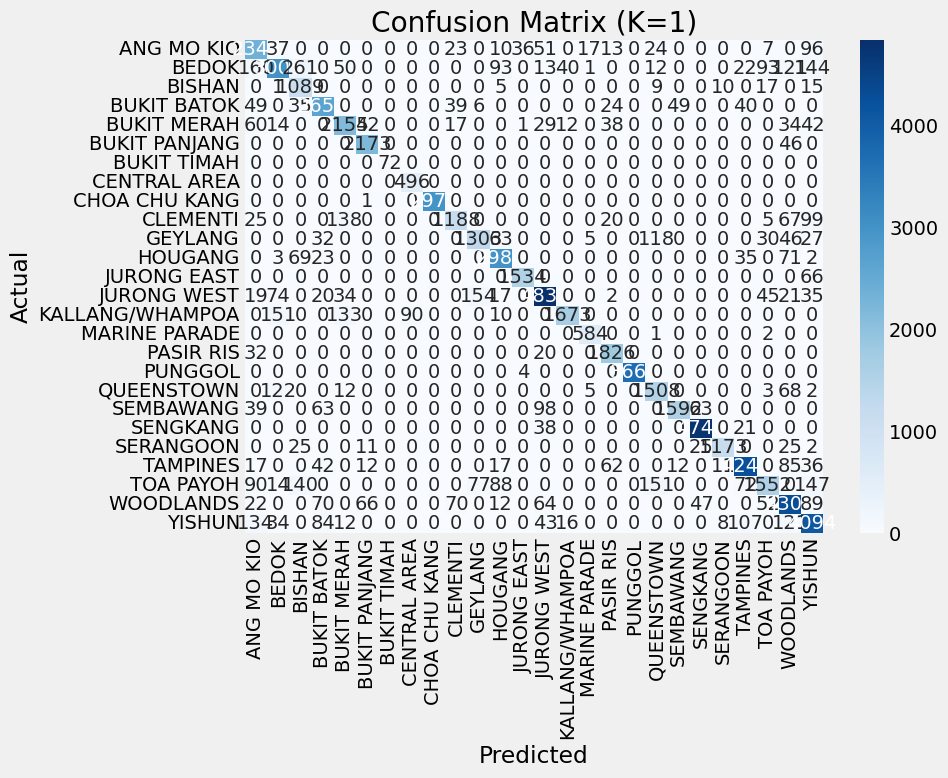

In [22]:
# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_labels,
            yticklabels=present_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (K={best_k})')
plt.tight_layout()
plt.show()

---

## Step 8: Define Model Evaluation Helper Functions

Create reusable functions to train each classifier and display its performance — mirroring the same pattern used for each model in Steps 9–12.


In [23]:
def extract_feature_importance(model, feature_columns):
    if hasattr(model, 'feature_importances_'):
        values = model.feature_importances_
    elif hasattr(model, 'coef_'):
        coef = model.coef_
        values = np.mean(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef)
    else:
        return pd.DataFrame(columns=['Feature', 'Importance'])

    importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': values
    }).sort_values('Importance', ascending=False).reset_index(drop=True)
    return importance_df

def evaluate_classification_model(model, X_train_data, X_test_data, y_train_data, y_test_data, model_name, feature_columns):
    start = time.perf_counter()
    model.fit(X_train_data, y_train_data)
    runtime = time.perf_counter() - start

    train_pred = model.predict(X_train_data)
    test_pred = model.predict(X_test_data)

    if 'CatBoost' in type(model).__name__:
        train_pred = np.array(train_pred).astype(int).ravel()
        test_pred = np.array(test_pred).astype(int).ravel()

    train_acc = accuracy_score(y_train_data, train_pred)
    test_acc = accuracy_score(y_test_data, test_pred)
    importance_df = extract_feature_importance(model, feature_columns)

    return {
        'Model': model_name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Runtime (sec)': runtime,
        'Feature Importance': importance_df,
        'fitted_model': model
    }

print("Reusable evaluation helpers defined.")

Reusable evaluation helpers defined.


In [24]:
# Prepare shared inputs used by every model evaluation cell (Steps 9–12).

# All models are evaluated on the SAME train/test split for a fair comparison.

# X_train, X_test, y_train, y_test were created in Step 5c.



# Class names — town labels in the same sorted order as the numeric encoding

class_names = [label for label, _ in sorted(TARGET_MAPPING.items(), key=lambda x: x[1])]



print(f"Shared train / test split : {len(X_train)} train | {len(X_test)} test")
print(f"Class names ({len(class_names)} towns)  : {class_names}")
print()

print("Note: Logistic Regression (Steps 6–7) uses X_train_scaled / X_test_scaled.")
print("      Tree models below use raw X_train / X_test.")


Shared train / test split : 393484 train | 66283 test
Class names (26 towns)  : ['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT BATOK', 'BUKIT MERAH', 'BUKIT PANJANG', 'BUKIT TIMAH', 'CENTRAL AREA', 'CHOA CHU KANG', 'CLEMENTI', 'GEYLANG', 'HOUGANG', 'JURONG EAST', 'JURONG WEST', 'KALLANG/WHAMPOA', 'MARINE PARADE', 'PASIR RIS', 'PUNGGOL', 'QUEENSTOWN', 'SEMBAWANG', 'SENGKANG', 'SERANGOON', 'TAMPINES', 'TOA PAYOH', 'WOODLANDS', 'YISHUN']

Note: Logistic Regression (Steps 6–7) uses X_train_scaled / X_test_scaled.
      Tree models below use raw X_train / X_test.


---

## Step 9a: Common parameters to modify


In [25]:
# MODIFY THIS CELL TO EVALUATE YOUR MODELS (Steps 9b–12)
N_ESTIMATORS = 300  # Number of trees in the forest (tune for better performance)

---

## Step 9b: Random Forest Model

An ensemble of decision trees that votes on the most likely class.  
No feature scaling required — Random Forest is scale-invariant.

In [26]:
# ========== RANDOM FOREST ==========
rf_model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE,
    class_weight='balanced_subsample',
    n_jobs=-1
)

rf_results = evaluate_classification_model(
    rf_model, X_train, X_test, y_train, y_test,
    'Random Forest', FEATURE_COLUMNS
)

print("Random Forest")
print(f"Train Accuracy: {rf_results['Train Accuracy']:.4f}")
print(f"Test Accuracy : {rf_results['Test Accuracy']:.4f}")
print(f"Runtime (sec) : {rf_results['Runtime (sec)']:.3f}")

Random Forest
Train Accuracy: 1.0000
Test Accuracy : 0.8693
Runtime (sec) : 46.147


In [27]:
print("Top Random Forest feature importance:")
print(rf_results['Feature Importance'].head(10).to_string(index=False))

Top Random Forest feature importance:
    Feature  Importance
live_hawker    0.257630
  live_mall    0.223970
   live_mrt    0.200658
   live_sec    0.159899
   live_pri    0.157843


---

## Step 10: LightGBM Model

Gradient boosting with fast leaf-wise tree growth.  
No feature scaling required — LightGBM is scale-invariant.


In [28]:
# ========== LIGHTGBM ==========
if LGBMClassifier is not None:
    lgbm_model = LGBMClassifier(
        objective='multiclass',
        num_class=len(TARGET_MAPPING),
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=6,
        min_child_samples=10,
        subsample=0.9,
        colsample_bytree=0.9,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    lgbm_results = evaluate_classification_model(
        lgbm_model, X_train, X_test, y_train, y_test,
        'LightGBM', FEATURE_COLUMNS
    )
    print("LightGBM")
    print(f"Train Accuracy: {lgbm_results['Train Accuracy']:.4f}")
    print(f"Test Accuracy : {lgbm_results['Test Accuracy']:.4f}")
    print(f"Runtime (sec) : {lgbm_results['Runtime (sec)']:.3f}")
else:
    print("LightGBM is not installed. Run: pip install lightgbm")
    lgbm_results = None

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001236 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 393484, number of used features: 5
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097

In [29]:
if lgbm_results is not None:
    print("Top LightGBM feature importance:")
    print(lgbm_results['Feature Importance'].head(10).to_string(index=False))

Top LightGBM feature importance:
    Feature  Importance
live_hawker       93979
   live_pri       91447
   live_mrt       89957
  live_mall       82959
   live_sec       81474


---

## Step 11: XGBoost Model

Gradient boosting with level-wise tree growth and built-in regularisation (L1/L2).  
No feature scaling required — XGBoost is scale-invariant.


In [30]:
# ========== XGBOOST ==========
if XGBClassifier is not None:
    required_vars = ['y_train_xgb', 'y_test_xgb', 'xgb_label_encoder']
    missing_vars = [var for var in required_vars if var not in globals()]
    if missing_vars:
        raise RuntimeError(f"Missing XGBoost label variables: {missing_vars}. Run the SMOTE preprocessing cell first.")

    xgb_model = XGBClassifier(
        n_estimators=N_ESTIMATORS,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='multi:softmax',
        num_class=len(xgb_label_encoder.classes_),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='mlogloss'
    )
    xgb_results = evaluate_classification_model(
        xgb_model, X_train, X_test, y_train_xgb, y_test_xgb,
        'XGBoost', FEATURE_COLUMNS
    )
    print("XGBoost")
    print(f"Train Accuracy: {xgb_results['Train Accuracy']:.4f}")
    print(f"Test Accuracy : {xgb_results['Test Accuracy']:.4f}")
    print(f"Runtime (sec) : {xgb_results['Runtime (sec)']:.3f}")
else:
    print("XGBoost is not installed. Run: pip install xgboost")
    xgb_results = None

XGBoost
Train Accuracy: 0.9935
Test Accuracy : 0.7806
Runtime (sec) : 76.058


In [31]:
if xgb_results is not None:
    print("Top XGBoost feature importance:")
    print(xgb_results['Feature Importance'].head(10).to_string(index=False))

Top XGBoost feature importance:
    Feature  Importance
live_hawker    0.277775
   live_mrt    0.217550
  live_mall    0.204586
   live_sec    0.152123
   live_pri    0.147966


---

## Step 12: CatBoost Model

Gradient boosting with built-in handling for class imbalance.  
No feature scaling required — CatBoost is scale-invariant.


In [32]:
# ========== CATBOOST ==========
if CatBoostClassifier is not None:
    catboost_model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='MultiClass',
        eval_metric='Accuracy',
        random_seed=RANDOM_STATE,
        verbose=0
    )
    catboost_results = evaluate_classification_model(
        catboost_model, X_train, X_test, y_train, y_test,
        'CatBoost', FEATURE_COLUMNS
    )
    print("CatBoost")
    print(f"Train Accuracy: {catboost_results['Train Accuracy']:.4f}")
    print(f"Test Accuracy : {catboost_results['Test Accuracy']:.4f}")
    print(f"Runtime (sec) : {catboost_results['Runtime (sec)']:.3f}")
else:
    print("CatBoost is not installed. Run: pip install catboost")
    catboost_results = None

CatBoost
Train Accuracy: 0.9499
Test Accuracy : 0.7964
Runtime (sec) : 170.837


In [33]:
if catboost_results is not None:
    print("Top CatBoost feature importance:")
    print(catboost_results['Feature Importance'].head(10).to_string(index=False))

Top CatBoost feature importance:
    Feature  Importance
live_hawker   26.310647
   live_mrt   21.999221
  live_mall   21.370402
   live_sec   16.010102
   live_pri   14.309629


In [34]:
print("CatBoost feature-importance chart removed (metrics-only workflow).")

CatBoost feature-importance chart removed (metrics-only workflow).


---

## Step 13: Model Comparison Summary

Rank all trained models side-by-side on the same train/test split.


In [35]:
all_comparison_results = [
    knn_results,
    rf_results,
    lgbm_results,
    xgb_results,
    catboost_results
]

all_comparison_results = [res for res in all_comparison_results if res is not None]

comparison_df = pd.DataFrame([
    {
        'Model': r['Model'],
        'Train Accuracy': round(r['Train Accuracy'], 4),
        'Test Accuracy': round(r['Test Accuracy'], 4),
        'Runtime (sec)': round(r['Runtime (sec)'], 3)
    }
    for r in all_comparison_results
]).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("Model comparison summary")
print(comparison_df.to_string(index=False))

print("\nBest model by test accuracy:")
print(comparison_df.loc[0, 'Model'])

print("\nTop 5 features per model:")
for res in all_comparison_results:
    print(f"\n{res['Model']}:")
    fi = res['Feature Importance']
    if fi.empty:
        print("No feature importance available.")
    else:
        print(fi.head(5).to_string(index=False))



Model comparison summary
        Model  Train Accuracy  Test Accuracy  Runtime (sec)
    KNN (K=1)          1.0000         0.9017          0.509
Random Forest          1.0000         0.8693         46.147
     LightGBM          1.0000         0.8126         57.215
     CatBoost          0.9499         0.7964        170.837
      XGBoost          0.9935         0.7806         76.058

Best model by test accuracy:
KNN (K=1)

Top 5 features per model:

KNN (K=1):
No feature importance available.

Random Forest:
    Feature  Importance
live_hawker    0.257630
  live_mall    0.223970
   live_mrt    0.200658
   live_sec    0.159899
   live_pri    0.157843

LightGBM:
    Feature  Importance
live_hawker       93979
   live_pri       91447
   live_mrt       89957
  live_mall       82959
   live_sec       81474

XGBoost:
    Feature  Importance
live_hawker    0.277775
   live_mrt    0.217550
  live_mall    0.204586
   live_sec    0.152123
   live_pri    0.147966

CatBoost:
    Feature  Importance

In [ ]:
# # ========== EXPORT CLASSIFICATION MODEL AND ARTEFACTS TO WEB APP ==========
# # Run this cell after training to update app/models/ with the latest model.
# # The web app (app/app.py) reads these files at startup.
# import joblib
# import json
# from pathlib import Path

# MODEL_DIR = Path("../app/models")
# MODEL_DIR.mkdir(exist_ok=True)

# # 1. Save the best classifier (Random Forest)
# joblib.dump(rf_results["fitted_model"], MODEL_DIR / "rf_classifier.joblib")
# print("Saved: rf_classifier.joblib")

# # 2. Save the fitted scaler (used to scale features before prediction)
# joblib.dump(scaler, MODEL_DIR / "scaler_classifier.joblib")
# print("Saved: scaler_classifier.joblib")

# # 3. Save the town class labels (index maps to town name, e.g. class 0 -> class_names[0])
# with open(MODEL_DIR / "town_classes.json", "w") as f:
#     json.dump(class_names, f, indent=2)
# print(f"Saved: town_classes.json  ({len(class_names)} towns)")
# for i, town in enumerate(class_names):
#     print(f"  {i}: {town}")

# print("
# All classification artefacts exported to app/models/")


---

## Summary

| Step | Model | Type | Notes |
|------|-------|------|-------|
| Step 6–7 | K-Nearest Neighbors | Distance-based | Optimal K determined from error analysis; uses feature scaling |
| Step 9   | Random Forest | Ensemble | 300 trees; balanced class weights; scale-invariant |
| Step 10  | LightGBM | Gradient Boosting | Fast leaf-wise growth; scale-invariant |
| Step 11  | XGBoost | Gradient Boosting | Level-wise with regularisation; scale-invariant |
| Step 12  | CatBoost | Gradient Boosting | Handles class imbalance; scale-invariant |
| Step 13  | Comparison | — | All models ranked on the same train/test split |

**How to reuse this notebook on a new dataset:**

1. Update `TARGET_COLUMN` and `DATA_PATH` in Steps 1–2
2. Adjust `FEATURE_COLUMNS` in Step 5b (and feature engineering in Step 3.5)
3. Re-run all cells — Steps 6–13 train and compare all models automatically
